Instalación requerimientos

In [4]:
pip install tensorflow matplotlib numpy scikit-learn

Se usara el dataset CIFAR-10

1. Cargar los datos

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


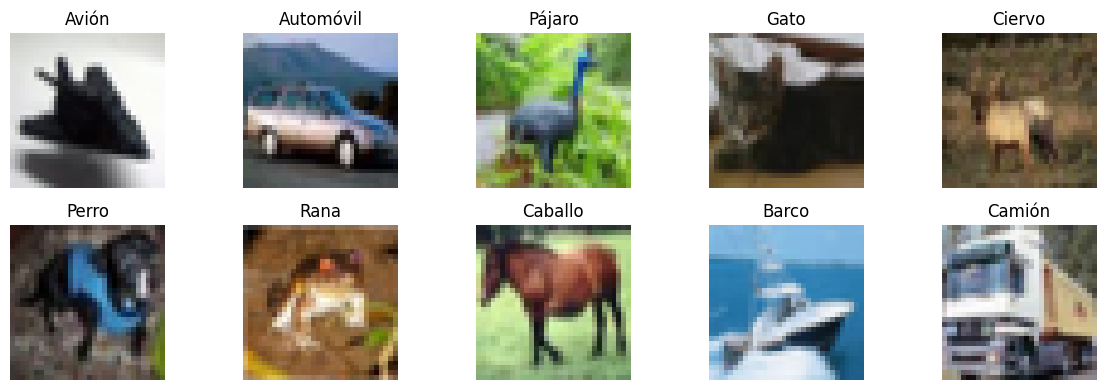

Nuevos tamaños:
Train: (40000, 32, 32, 3)
Val: (10000, 32, 32, 3)
Test (sin tocar): (10000, 32, 32, 3)

Distribución en entrenamiento:
Clase 0: 4000
Clase 1: 4000
Clase 2: 4000
Clase 3: 4000
Clase 4: 4000
Clase 5: 4000
Clase 6: 4000
Clase 7: 4000
Clase 8: 4000
Clase 9: 4000

Distribución en validación:
Clase 0: 1000
Clase 1: 1000
Clase 2: 1000
Clase 3: 1000
Clase 4: 1000
Clase 5: 1000
Clase 6: 1000
Clase 7: 1000
Clase 8: 1000
Clase 9: 1000


In [5]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Cargar dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalizar
x_train = x_train / 255.0

# Nombres de clases
clases = ['Avión', 'Automóvil', 'Pájaro', 'Gato', 'Ciervo',
          'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']

# Buscar la primera imagen de cada clase
imagenes_por_clase = []
for clase_id in range(10):
    idx = np.where(y_train == clase_id)[0][0]  # primer índice donde aparece la clase
    imagenes_por_clase.append((x_train[idx], clases[clase_id]))

# Visualizar una imagen por clase
plt.figure(figsize=(12, 4))
for i, (img, nombre) in enumerate(imagenes_por_clase):
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(nombre)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Posteriormente separar los datos de train en validation y train, el dataset ya viene separado en train y test

# Dividir x_train original en entrenamiento y validación
x_train_sub, x_val, y_train_sub, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print("Nuevos tamaños:")
print("Train:", x_train_sub.shape)
print("Val:", x_val.shape)
print("Test (sin tocar):", x_test.shape)

# Verificar que haya mismo numero en cada clase
def contar_clases(y, nombre):
    clases, counts = np.unique(y, return_counts=True)
    print(f"\nDistribución en {nombre}:")
    for c, count in zip(clases, counts):
        print(f"Clase {c}: {count}")

contar_clases(y_train_sub, "entrenamiento")
contar_clases(y_val, "validación")

2. Crear un modelo CNN básico

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense, Dropout

# Definir modelo CNN siguiendo la arquitectura
model = Sequential([
    # Primera etapa: Conv → ReLU → MaxPool
    Conv2D(filters=32, kernel_size=(3,3), padding='same', input_shape=(32,32,3)),
    Activation('relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Segunda etapa: Conv → ReLU → MaxPool
    Conv2D(filters=64, kernel_size=(3,3), padding='same'),
    Activation('relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Aplanar y capa densa
    Flatten(),
    Dense(128),
    Activation('relu'),
    Dropout(0.5),

    # Capa de salida (softmax para multiclase)
    Dense(10),
    Activation('softmax')
])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Explicación de parámetros clave:

**Conv2D(...)**:

Extrae características visuales (bordes, texturas, formas) de la imagen.

* filters=32 o 64: Número de filtros o kernels. Cuantos más, más patrones puede aprender.

* kernel_size=(3,3): Tamaño del filtro (3x3 es estándar).

* activation='relu': Aplica la función ReLU (Rectified Linear Unit), que introduce no linealidad (mejora el aprendizaje).

* padding='same': Rellena los bordes para que la salida tenga el mismo tamaño que la entrada.

* input_shape=(32,32,3): Tamaño de entrada (imagen CIFAR-10: 32x32 píxeles, 3 canales RGB). Solo se especifica en la primera capa

=========================================

**MaxPooling2D(...)**

Reduce tamaño espacial (ancho x alto), manteniendo características importantes.

* pool_size=(2,2): Reduce a la mitad la dimensión con el valor máximo en cada bloque 2x2.

=========================================

**Flatten()**

Convierte la salida 2D de los filtros en un vector 1D, listo para la capa densa.

=========================================

**Dense(...)**

Capa neuronal clásica (completamente conectada).

* Dense(128, activation='relu'): Capa con 128 neuronas y ReLU.

* Dropout(0.5): Desactiva aleatoriamente el 50% de las neuronas durante el entrenamiento (reduce overfitting).

* Dense(10, activation='softmax'): Capa de salida, una neurona por clase. softmax transforma los valores en probabilidades que suman 1.

========================================

**Activaciones**

* ReLU: max(0, x). Acelera el entrenamiento, evita saturaciones.

* Softmax: Distribuye la salida final en probabilidades para clasificación multiclase.


===========================================

3. Entrenar el modelo

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    x_train_sub, y_train_sub,
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)



Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 123ms/step - accuracy: 0.3038 - loss: 1.8892 - val_accuracy: 0.5409 - val_loss: 1.3246
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 112ms/step - accuracy: 0.4972 - loss: 1.3958 - val_accuracy: 0.6067 - val_loss: 1.1533
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 107ms/step - accuracy: 0.5615 - loss: 1.2390 - val_accuracy: 0.6296 - val_loss: 1.0790
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 106ms/step - accuracy: 0.5972 - loss: 1.1448 - val_accuracy: 0.6531 - val_loss: 1.0011
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 102ms/step - accuracy: 0.6185 - loss: 1.0814 - val_accuracy: 0.6274 - val_loss: 1.0529
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 105ms/step - accuracy: 0.6431 - loss: 1.0142 - val_accuracy: 0.6737 - val_loss: 0.9382
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.6625 - loss: 0.9566 - val_accuracy: 0.6833 - val_loss: 0.9240
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 102ms/step - accuracy: 0.6743 - loss: 0

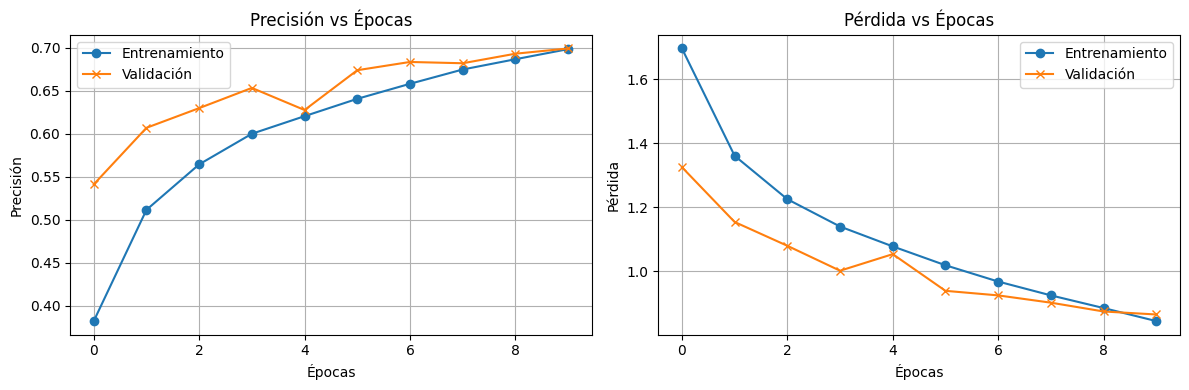

In [9]:
import matplotlib.pyplot as plt

# Crear gráfico de precisión
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento', marker='o')
plt.plot(history.history['val_accuracy'], label='Validación', marker='x')
plt.title('Precisión vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento', marker='o')
plt.plot(history.history['val_loss'], label='Validación', marker='x')
plt.title('Pérdida vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


========================================

4. Evaluar y visualizar resultados

In [10]:
# Evaluación final del modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
print(f"Precisión final en test: {test_accuracy:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5498 - loss: 132.2232
Precisión final en test: 0.5475


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


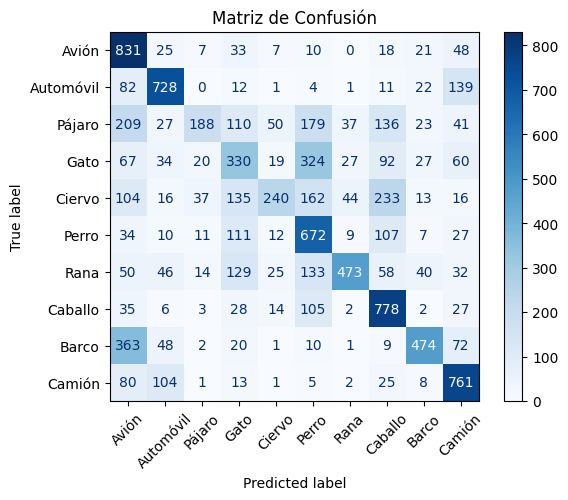

In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predicciones
y_pred_probs = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# Etiquetas de clases CIFAR-10
clases = ['Avión', 'Automóvil', 'Pájaro', 'Gato', 'Ciervo',
          'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matriz de Confusión")
plt.grid(False)
plt.show()


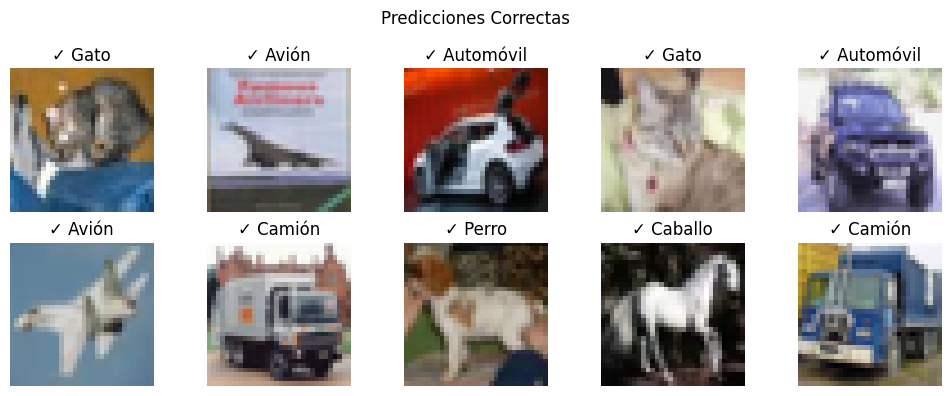

In [12]:
import matplotlib.pyplot as plt

# Índices de predicciones correctas
aciertos = np.where(y_pred_classes == y_true)[0]

# Mostrar 10 aciertos
plt.figure(figsize=(10, 4))
for i, idx in enumerate(aciertos[:10]):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[idx])
    plt.title(f"✓ {clases[y_true[idx]]}")
    plt.axis('off')
plt.suptitle("Predicciones Correctas")
plt.tight_layout()
plt.show()


/tmp/ipython-input-13-175001867.py:12: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


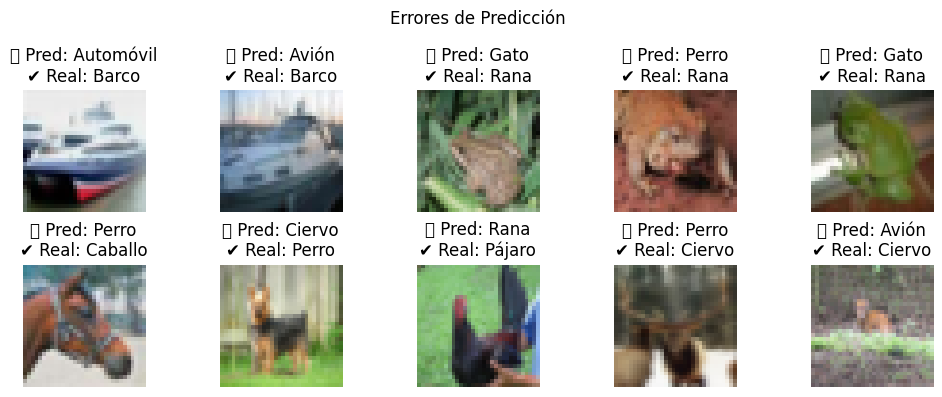

In [13]:
# Índices de errores
errores = np.where(y_pred_classes != y_true)[0]

# Mostrar 10 errores
plt.figure(figsize=(10, 4))
for i, idx in enumerate(errores[:10]):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[idx])
    plt.title(f"❌ Pred: {clases[y_pred_classes[idx]]}\n✔ Real: {clases[y_true[idx]]}")
    plt.axis('off')
plt.suptitle("Errores de Predicción")
plt.tight_layout()
plt.show()
